# Grammar Motif Analysis by HMM Regime
This notebook mirrors the catRQA analysis to test whether HMM regimes differ in the symbolic microstructure of joint affect sequences using grammar-style motif statistics (shuffle null only).

In [9]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal, spearmanr
import scikit_posthocs as sp
import yaml

# plotting defaults
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["svg.fonttype"] = "none"  # editable text in SVG
sns.set(style="whitegrid")

In [10]:
# --- 1) Load config and data ---
project_root = Path.cwd().parent
with open(project_root / "configs/analysis.yaml") as f:
    cfg = yaml.safe_load(f)

ga_cfg = cfg["analysis"]["joint_affect_grammar"]
hmm_dir = project_root / ga_cfg["hmm_dir"]
out_dir = project_root / ga_cfg["out_dir"]
figure_dir = out_dir / "notebook_figures"
figure_dir.mkdir(parents=True, exist_ok=True)

# Load grammar episode results (script output)
episode_df = pd.read_csv(out_dir / "grammar_episode_results.csv")

# Use shuffle-only stats; ignore Markov columns entirely
shuffle_cols = [c for c in episode_df.columns if "_shuffle" in c or c.endswith("_shuffle") or c.endswith("_two_shuffle") or c.endswith("_hi_shuffle") or c.endswith("_lo_shuffle") or c.endswith("_z_shuffle")]

# Keep only k in {2,3}
episode_df = episode_df[episode_df["k"].isin([2, 3])].copy()

# Load HMM regime labels for regime_class mapping
with open(hmm_dir / "best_model.json") as f:
    hmm_params = json.load(f)
pT = np.array(hmm_params["pT"])
pC = np.array(hmm_params["pC"])
regime_classes = []
for k_idx in range(pT.shape[0]):
    t_val = ["Tneg", "Tneu", "Tpos"][np.argmax(pT[k_idx, :])]
    c_val = ["Cneg", "Cneu", "Cpos"][np.argmax(pC[k_idx, :])]
    regime_classes.append(f"{t_val}-{c_val}")

# Canonical ordering (match catRQA): sort by therapist valence, then client valence, then hashed emissions
therapist_valence = np.argmax(pT, axis=1)
client_valence = np.argmax(pC, axis=1)
sort_key = (
    therapist_valence * 1_000_000
    + client_valence * 1_000
    + np.array([(hash(str(pT[k])) + hash(str(pC[k]))) % 1000 for k in range(pT.shape[0])])
 )
order = np.argsort(sort_key)
order_rank = {reg: i for i, reg in enumerate(order)}
regime_class_by_regime = {k: regime_classes[k] for k in range(len(regime_classes))}

# Keep only episodes with valid shuffle stats and enough windows
MIN_NULL_WINDOWS = 30  # aligns with script defaults
shuffle_z_cols = ["motif_entropy_z_shuffle","effective_motif_count_z_shuffle","top_mass_top_n_z_shuffle","repeat_rate_z_shuffle","motif_transition_diversity_z_shuffle"]
episode_df = episode_df[episode_df["n_windows"] >= MIN_NULL_WINDOWS]
episode_df = episode_df.dropna(subset=shuffle_z_cols)

# Add regime class
episode_df["regime_class"] = episode_df["regime"].map(regime_class_by_regime)

In [11]:
# --- 2) Episode -> session -> dyad aggregation (length-weighted) ---
metrics = [
    "motif_entropy_z_shuffle",
    "effective_motif_count_z_shuffle",
    "top_mass_top_n_z_shuffle",
    "repeat_rate_z_shuffle",
    "motif_transition_diversity_z_shuffle",
]

# helper
def weighted_mean(df, value_col, weight_col):
    total_w = df[weight_col].sum()
    if total_w == 0:
        return np.nan
    return (df[value_col] * df[weight_col]).sum() / total_w

# session-level aggregation (within session/regime/k)
session_level = (
    episode_df.groupby(["session_id", "dyad_id", "regime", "regime_class", "k"]).apply(
        lambda df: pd.Series({
            **{m: weighted_mean(df, m, "duration") for m in metrics},
            "total_duration": df["duration"].sum(),
            "n_episodes": len(df),
        })
    )
    .reset_index()
)

# dyad-level aggregation (within dyad/regime/k)
dyad_level = (
    session_level.groupby(["dyad_id", "regime", "regime_class", "k"]).apply(
        lambda df: pd.Series({
            **{m: weighted_mean(df, m, "total_duration") for m in metrics},
            "total_duration": df["total_duration"].sum(),
            "n_sessions": len(df),
        })
    )
    .reset_index()
)

# Filter to regimes that appear in data and build ordered category for plotting
present_regimes = sorted(dyad_level["regime"].unique())
class_order = []
for reg in order:
    if reg in present_regimes:
        rc = regime_class_by_regime[reg]
        if rc not in class_order:
            class_order.append(rc)
dyad_level = dyad_level.copy()
dyad_level["regime_class"] = pd.Categorical(dyad_level["regime_class"], categories=class_order, ordered=True)

print("Episode rows:", len(episode_df))
print("Session rows:", len(session_level))
print("Dyad rows:", len(dyad_level))
dyad_level.head()

Episode rows: 470
Session rows: 234
Dyad rows: 218


/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_31660/1408799965.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  episode_df.groupby(["session_id", "dyad_id", "regime", "regime_class", "k"]).apply(
/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_31660/1408799965.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  session_level.groupby(["dyad_id", "regime", "regime_class", "k"]).apply(


,dyad_id,regime,regime_class,k,motif_entropy_z_shuffle,effective_motif_count_z_shuffle,top_mass_top_n_z_shuffle,repeat_rate_z_shuffle,motif_transition_diversity_z_shuffle,total_duration,n_sessions
0,2,7,Tpos-Cneu,2,0.217072,0.217072,0.000000,-0.321634,0.318747,36.0,1.0
1,2,7,Tpos-Cneu,3,0.380609,0.384010,0.000000,-0.457517,0.451890,36.0,1.0
2,4,2,Tneu-Cneg,2,0.691827,0.700576,0.460566,-1.293203,1.222604,31.0,1.0
3,4,7,Tpos-Cneu,2,0.000000,0.000000,0.000000,0.000000,0.000000,49.0,1.0
4,4,7,Tpos-Cneu,3,0.000000,0.000000,0.000000,0.000000,0.000000,49.0,1.0


In [12]:
# --- 3) Sanity checks (brief) ---
for k_val in [2, 3]:
    sub = episode_df[episode_df["k"] == k_val]
    print(f"\nSanity for k={k_val} (episode-level):")
    for m in metrics:
        vals = sub[m].dropna()
        print(f"  {m}: mean={vals.mean():.3f}, sd={vals.std():.3f}, n={len(vals)}")
    # duration correlations (episode-level)
    for m in metrics:
        vals = sub[[m, "duration"]].dropna()
        if len(vals) > 2:
            rho, p = spearmanr(vals[m], vals["duration"])
            print(f"    corr(duration,{m}) rho={rho:.3f}, p={p:.3f}")


Sanity for k=2 (episode-level):
  motif_entropy_z_shuffle: mean=-0.043, sd=0.945, n=244
  effective_motif_count_z_shuffle: mean=-0.043, sd=0.941, n=244
  top_mass_top_n_z_shuffle: mean=0.116, sd=0.826, n=244
  repeat_rate_z_shuffle: mean=-0.017, sd=1.012, n=244
  motif_transition_diversity_z_shuffle: mean=0.042, sd=1.004, n=244
    corr(duration,motif_entropy_z_shuffle) rho=-0.010, p=0.880
    corr(duration,effective_motif_count_z_shuffle) rho=-0.009, p=0.895
    corr(duration,top_mass_top_n_z_shuffle) rho=0.128, p=0.046
    corr(duration,repeat_rate_z_shuffle) rho=-0.037, p=0.564
    corr(duration,motif_transition_diversity_z_shuffle) rho=0.048, p=0.458

Sanity for k=3 (episode-level):
  motif_entropy_z_shuffle: mean=-0.118, sd=1.011, n=226
  effective_motif_count_z_shuffle: mean=-0.112, sd=0.992, n=226
  top_mass_top_n_z_shuffle: mean=0.200, sd=0.993, n=226
  repeat_rate_z_shuffle: mean=-0.027, sd=1.029, n=226
  motif_transition_diversity_z_shuffle: mean=-0.007, sd=1.008, n=226
    

In [17]:
# --- 4) Regime-level statistical tests (Kruskal + Dunn) ---
from collections import defaultdict

kw_rows = []
dunn_sig_pairs = defaultdict(list)  # (k, metric) -> list of (pair, p)
dunn_rows = []  # collect all pairwise contrasts
for k_val in [2, 3]:
    sub = dyad_level[dyad_level["k"] == k_val].dropna(subset=metrics)
    for m in metrics:
        groups = [sub.loc[sub["regime"] == reg, m].dropna().values for reg in present_regimes if reg in sub["regime"].unique()]
        groups = [g for g in groups if len(g) > 0]
        if len(groups) < 2:
            continue
        H, p_kw = kruskal(*groups)
        kw_rows.append({"k": k_val, "metric": m, "H": H, "p": p_kw})
        if p_kw < 0.05:
            dunn = sp.posthoc_dunn(sub, val_col=m, group_col="regime", p_adjust="bonferroni")
            # collect all pairwise contrasts (i<j)
            for i, reg_i in enumerate(dunn.index):
                for j, reg_j in enumerate(dunn.columns):
                    if j <= i:
                        continue
                    p_val = dunn.iloc[i, j]
                    pair = f"R{reg_i+1} vs R{reg_j+1}"
                    dunn_rows.append({"k": k_val, "metric": m, "pair": pair, "p": p_val})
                    if p_val < 0.05:
                        dunn_sig_pairs[(k_val, m)].append((pair, p_val))

kw_table = pd.DataFrame(kw_rows).sort_values(["k", "p"]) 
print("Kruskal-Wallis results (sorted by k then p):")
display(kw_table)

# Display all pairwise Dunn contrasts in a compact table (sorted)
if dunn_rows:
    dunn_df = pd.DataFrame(dunn_rows).sort_values(["k", "metric", "p"])
    print('\nAll pairwise Dunn contrasts (Bonferroni-corrected p-values):')
    display(dunn_df)
else:
    print('\nNo pairwise Dunn contrasts were computed.')

# Build compact textual summary of notable contrasts (p<0.01)
summary_lines = []
for (k_val, m), pairs in dunn_sig_pairs.items():
    strong = [f"{pair} (p={p:.3g})" for pair, p in pairs if p < 0.01]
    if strong:
        summary_lines.append(f"k={k_val}, {m}: " + "; ".join(strong))
if summary_lines:
    print("\nNotable contrasts (p<0.01):")
    for line in summary_lines:
        print("  - " + line)
else:
    print("\nNo pairwise contrasts below p<0.01.")

Kruskal-Wallis results (sorted by k then p):


,k,metric,H,p
3,2,repeat_rate_z_shuffle,31.207438,0.000009
4,2,motif_transition_diversity_z_shuffle,29.278767,0.000020
1,2,effective_motif_count_z_shuffle,15.044559,0.010174
0,2,motif_entropy_z_shuffle,14.830588,0.011111
2,2,top_mass_top_n_z_shuffle,11.429761,0.043494
9,3,motif_transition_diversity_z_shuffle,29.478641,0.000019
7,3,top_mass_top_n_z_shuffle,26.145770,0.000084
8,3,repeat_rate_z_shuffle,23.300498,0.000296
5,3,motif_entropy_z_shuffle,19.419162,0.001605
6,3,effective_motif_count_z_shuffle,19.039090,0.001890



All pairwise Dunn contrasts (Bonferroni-corrected p-values):


,k,metric,pair,p
15,2,effective_motif_count_z_shuffle,R3 vs R4,0.010196
21,2,effective_motif_count_z_shuffle,R4 vs R6,0.026500
20,2,effective_motif_count_z_shuffle,R4 vs R5,0.410313
16,2,effective_motif_count_z_shuffle,R3 vs R5,1.000000
17,2,effective_motif_count_z_shuffle,R3 vs R6,1.000000
...,...,...,...,...
114,3,top_mass_top_n_z_shuffle,R5 vs R6,1.000000
115,3,top_mass_top_n_z_shuffle,R5 vs R7,1.000000
116,3,top_mass_top_n_z_shuffle,R5 vs R8,1.000000
118,3,top_mass_top_n_z_shuffle,R6 vs R8,1.000000



Notable contrasts (p<0.01):
  - k=2, repeat_rate_z_shuffle: R3 vs R4 (p=8.55e-05); R3 vs R7 (p=0.00188)
  - k=2, motif_transition_diversity_z_shuffle: R3 vs R4 (p=5.91e-05); R3 vs R7 (p=0.00602)
  - k=3, motif_entropy_z_shuffle: R3 vs R4 (p=0.00164)
  - k=3, effective_motif_count_z_shuffle: R3 vs R4 (p=0.00186)
  - k=3, top_mass_top_n_z_shuffle: R4 vs R5 (p=0.00409); R4 vs R6 (p=3.04e-05)
  - k=3, repeat_rate_z_shuffle: R3 vs R7 (p=0.00107)
  - k=3, motif_transition_diversity_z_shuffle: R3 vs R4 (p=0.000518); R3 vs R7 (p=0.000747)


/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_31660/807743342.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_31660/807743342.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_31660/807743342.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_31660/807743342.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and w

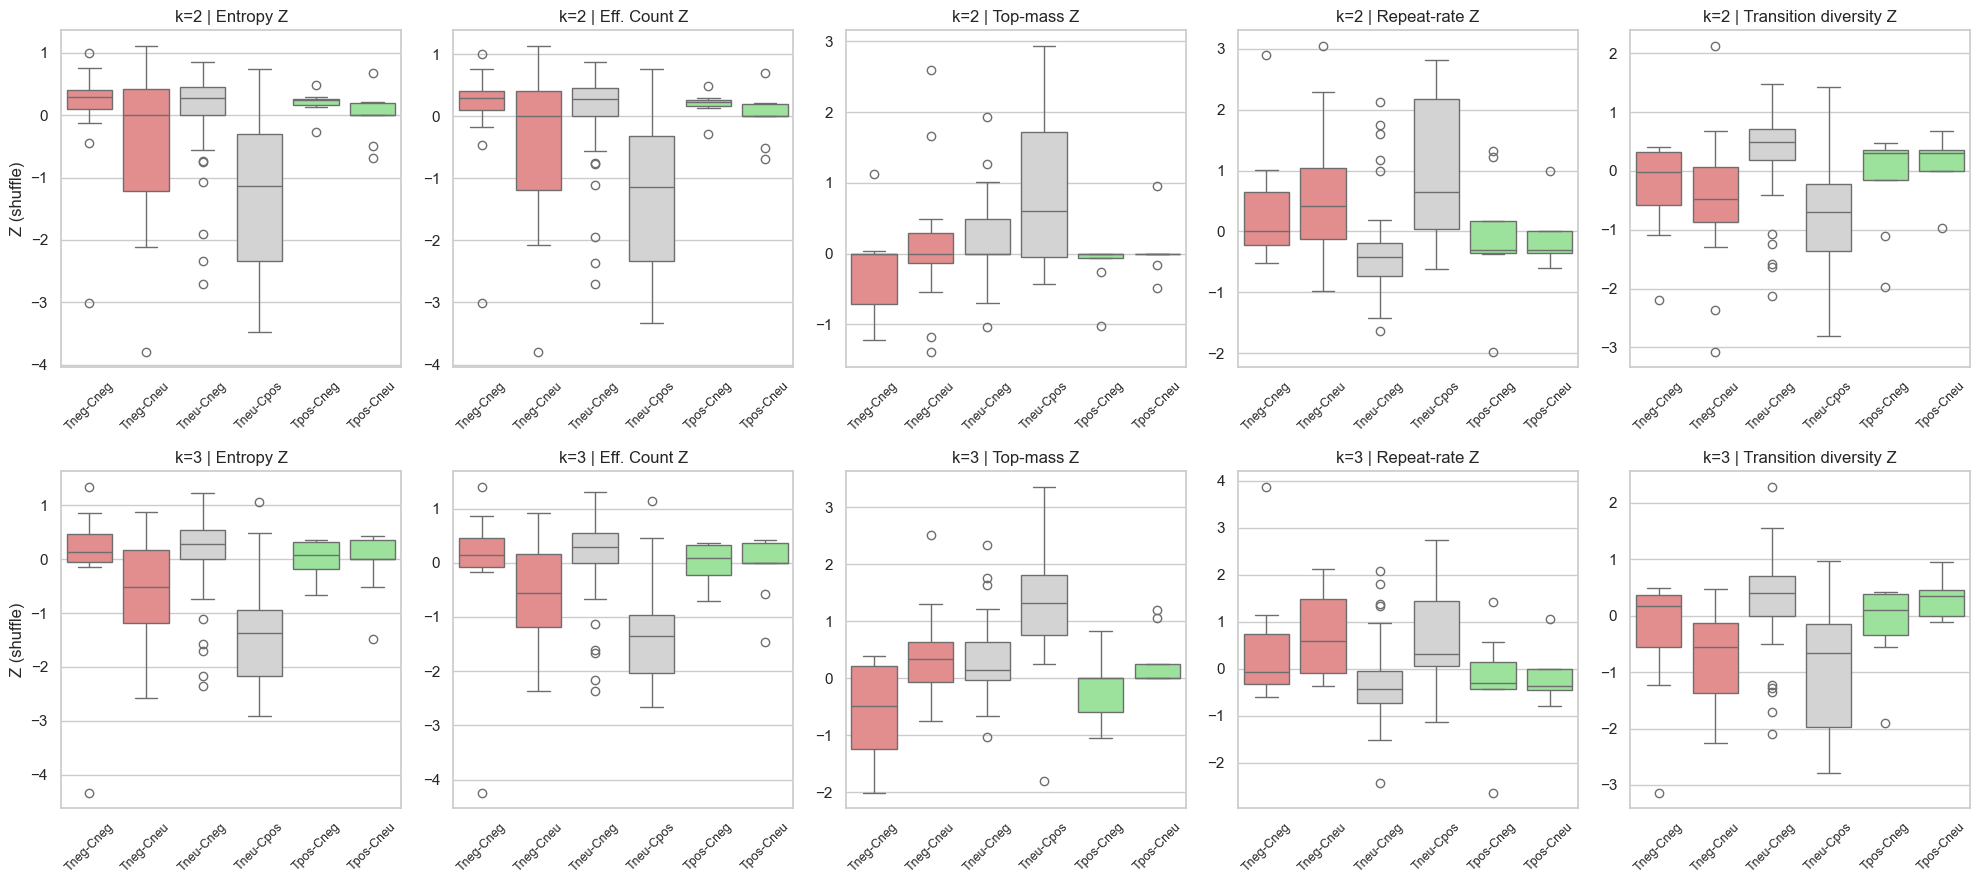

In [14]:
# --- 5) Figure: dyad-level Z-scores by regime_class (shuffle only) ---
palette = {"Tneg": "lightcoral", "Tneu": "lightgray", "Tpos": "lightgreen"}
metric_labels = {
    "motif_entropy_z_shuffle": "Entropy Z",
    "effective_motif_count_z_shuffle": "Eff. Count Z",
    "top_mass_top_n_z_shuffle": "Top-mass Z",
    "repeat_rate_z_shuffle": "Repeat-rate Z",
    "motif_transition_diversity_z_shuffle": "Transition diversity Z",
}

n_metrics = len(metrics)
fig, axes = plt.subplots(2, n_metrics, figsize=(4 * n_metrics, 9), sharey=False)
for row_idx, k_val in enumerate([2, 3]):
    sub = dyad_level[dyad_level["k"] == k_val]
    for col_idx, m in enumerate(metrics):
        ax = axes[row_idx, col_idx]
        sns.boxplot(
            data=sub,
            x="regime_class",
            y=m,
            order=class_order,
            palette=[palette[rc.split('-')[0]] for rc in class_order],
            ax=ax,
        )
        ax.set_title(f"k={k_val} | {metric_labels[m]}")
        ax.set_xlabel("")
        if col_idx == 0:
            ax.set_ylabel("Z (shuffle)")
        else:
            ax.set_ylabel("")
        ax.tick_params(axis="x", rotation=45, labelsize=9)
plt.tight_layout()
fig.savefig(figure_dir / "grammar_shuffle_z_by_regime_class.svg", format="svg")
plt.show()

In [16]:
# --- 6) Compact tables for reporting ---
kw_display = kw_table.copy()
kw_display["metric"] = kw_display["metric"].map(metric_labels)
print("Kruskal-Wallis summary (H, p):")
display(kw_display)

# Build a short narrative summary of dominant contrasts (p<0.001)
narrative_lines = []
for (k_val, m), pairs in dunn_sig_pairs.items():
    strong_pairs = [pair for pair, p in pairs if p < 0.001]
    if strong_pairs:
        metric_name = metric_labels[m]
        joined = ", ".join(strong_pairs)
        narrative_lines.append(f"k={k_val}, {metric_name}: {joined} (all p < .001)")
if narrative_lines:
    print("\nDominant contrasts (p < .001):")
    for line in narrative_lines:
        print("  - " + line)
else:
    print("\nNo dominant contrasts with p < .001.")

Kruskal-Wallis summary (H, p):


,k,metric,H,p
3,2,Repeat-rate Z,31.207438,0.000009
4,2,Transition diversity Z,29.278767,0.000020
1,2,Eff. Count Z,15.044559,0.010174
0,2,Entropy Z,14.830588,0.011111
2,2,Top-mass Z,11.429761,0.043494
9,3,Transition diversity Z,29.478641,0.000019
7,3,Top-mass Z,26.145770,0.000084
8,3,Repeat-rate Z,23.300498,0.000296
5,3,Entropy Z,19.419162,0.001605
6,3,Eff. Count Z,19.039090,0.001890



Dominant contrasts (p < .001):
  - k=2, Repeat-rate Z: R3 vs R4 (all p < .001)
  - k=2, Transition diversity Z: R3 vs R4 (all p < .001)
  - k=3, Top-mass Z: R4 vs R6 (all p < .001)
  - k=3, Transition diversity Z: R3 vs R4, R3 vs R7 (all p < .001)


/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_31660/1831383652.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_31660/1831383652.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


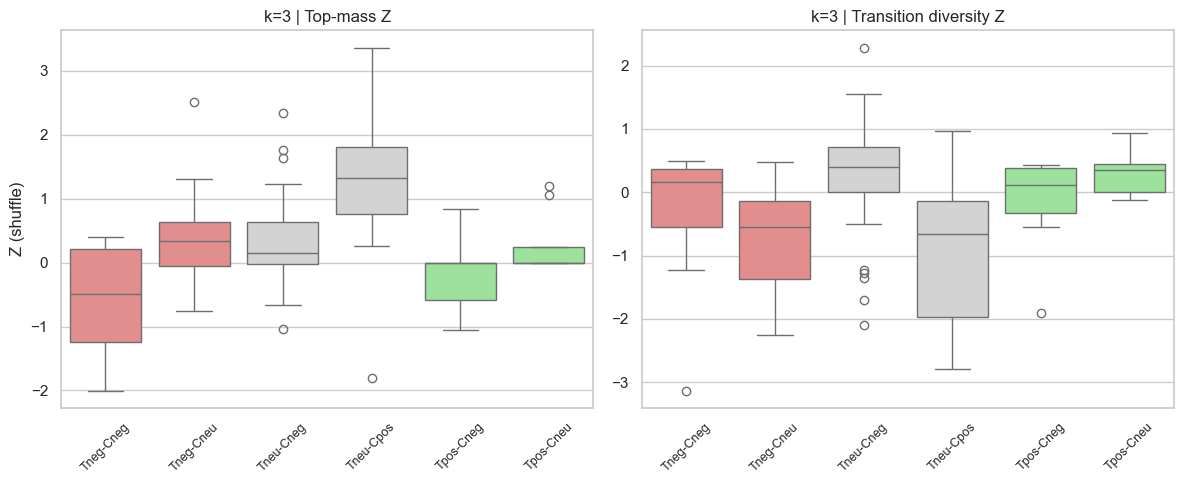

In [18]:
# --- Extra figure: k=3 Top-mass Z (left) and Transition diversity Z (right) ---
k_val = 3
sub = dyad_level[dyad_level["k"] == k_val]
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

# Left: Top-mass Z
sns.boxplot(
    data=sub,
    x="regime_class",
    y="top_mass_top_n_z_shuffle",
    order=class_order,
    palette=[palette[rc.split('-')[0]] for rc in class_order],
    ax=axes[0],
)
axes[0].set_title(f"k={k_val} | Top-mass Z")
axes[0].set_xlabel("")
axes[0].set_ylabel("Z (shuffle)")
axes[0].tick_params(axis="x", rotation=45, labelsize=9)

# Right: Transition diversity Z
sns.boxplot(
    data=sub,
    x="regime_class",
    y="motif_transition_diversity_z_shuffle",
    order=class_order,
    palette=[palette[rc.split('-')[0]] for rc in class_order],
    ax=axes[1],
)
axes[1].set_title(f"k={k_val} | Transition diversity Z")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=45, labelsize=9)

plt.tight_layout()
fig.savefig(figure_dir / "grammar_k3_topmass_transition_z_by_regime.svg", format="svg")
plt.show()
